In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix

Let´sLoad the dataset

In [16]:
data = pd.read_csv('data.csv')

Missing Value Handling

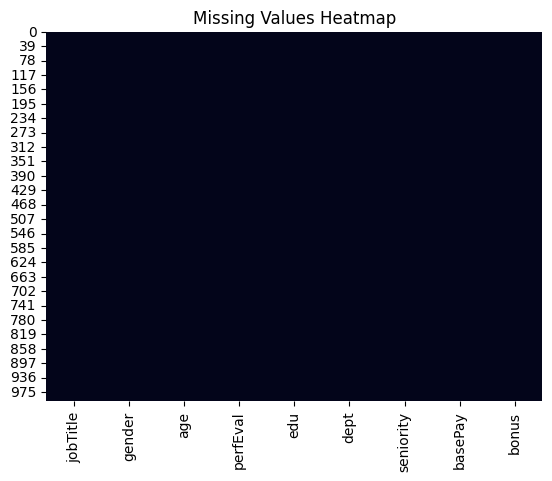

In [17]:
missing_values = data.isnull().sum()
sns.heatmap(data.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Data Visualization

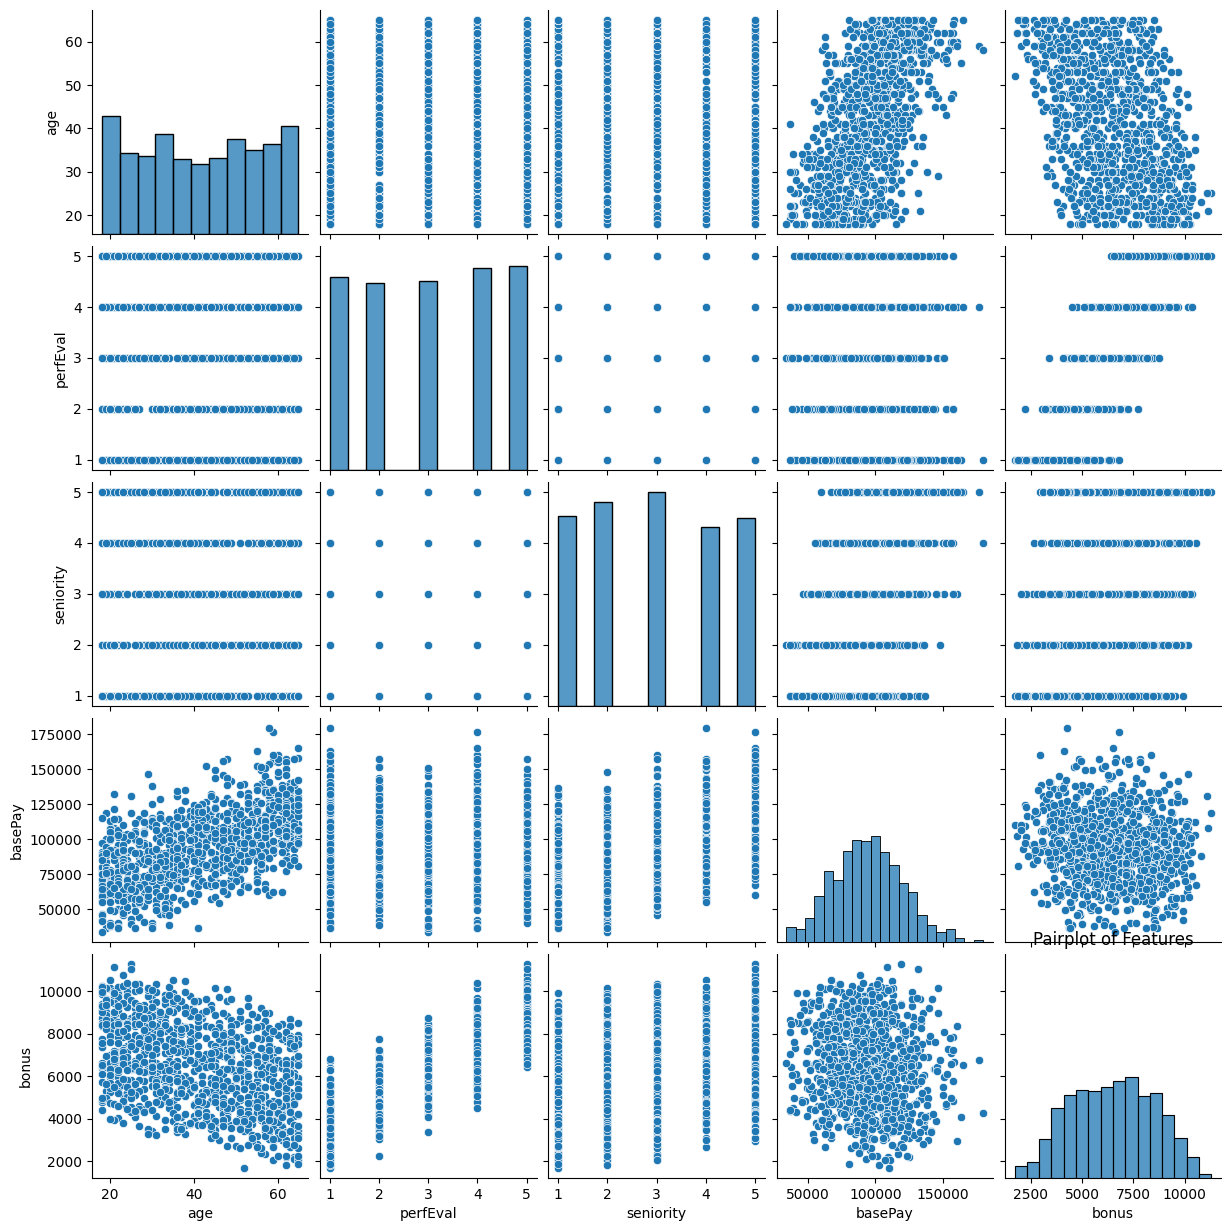

In [18]:
sns.pairplot(data)
plt.title("Pairplot of Features")
plt.show()

Data Transformation

In [19]:
numeric_columns = data.select_dtypes(include=[np.number]).columns
data_numeric = data[numeric_columns]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

Clustering using KMeans

In [20]:
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(data_scaled)
data['Cluster'] = clusters

Silhouette Score for Clustering

In [21]:
silhouette_avg = silhouette_score(data_scaled, clusters)
print(f"Silhouette Score: {silhouette_avg}")

Silhouette Score: 0.24895838536076628


Classification using K-Nearest Neighbors

In [22]:
X = data_scaled[:, :-2]
y = data['Cluster']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)
y_pred = knn_classifier.predict(X_test)

Accuracy for Classification

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.915


Confusion Matrix for Classification

In [24]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[44  2  4]
 [ 1 65  5]
 [ 1  4 74]]


 Regression using Ridge

In [25]:
X_regression = data_scaled[:, :-1]
y_regression = data_scaled[:, -1]
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression, y_regression, test_size=0.2, random_state=42)
alpha = 0.1
ridge_model = Ridge(alpha=alpha)
ridge_model.fit(X_train_regression, y_train_regression)
y_pred_regression = ridge_model.predict(X_test_regression)

Evaluation for Regression

In [26]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test_regression, y_pred_regression)
print(f"Mean Squared Error (Regression): {mse}")

Mean Squared Error (Regression): 0.11414174597051625


Visualization of Actual vs. Predicted (Regression)

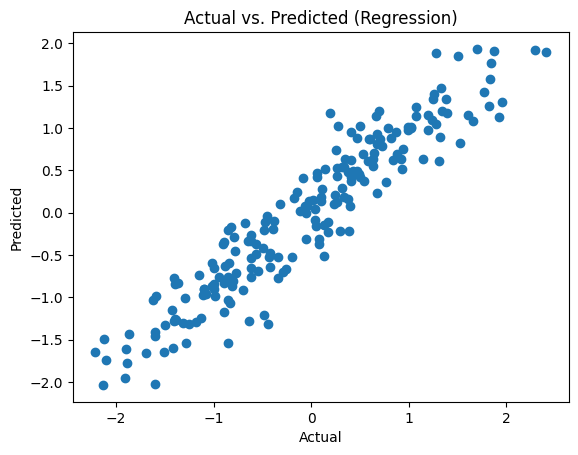

In [27]:
plt.scatter(y_test_regression, y_pred_regression)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs. Predicted (Regression)")
plt.show()